<a href="https://colab.research.google.com/github/JorgeMarquezPiedra/Sistemas-de-Capatacion-de-Lluvia-Ciudad-de-Mexico-2019-a-2024/blob/main/Sistemas_Captaci%C3%B3n_de_Lluvia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cargar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
# Leer datasets
cll_2019 = pd.read_csv('scall_2019.csv', encoding='latin1')
cll_2020 = pd.read_csv('scall_2020.csv', encoding='latin1')
cll_2021 = pd.read_csv('scall_2021.csv', encoding='latin1')
cll_2022 = pd.read_csv('scall_11_2022.csv', encoding='latin1')
cll_2024 = pd.read_csv('scall_2024.csv', encoding='latin1')

In [3]:
cll_2019

,long,lat,Expediente,Pueblo,Colonia_Ba,Territoria,Alcaldia,Fecha_de_I,Instalado
0,-98.975686,19.328924,J16NRB,TEOTONGO ACAHUALTEPEC,CAMPESTRE POTRERO,TEOTONGO ACAHUALTEPEC,IZTAPALAPA,2019-07-24,Programa SCALL
1,-98.970402,19.327016,J5WU9F,TEOTONGO ACAHUALTEPEC,CAMPESTRE POTRERO,TEOTONGO ACAHUALTEPEC,IZTAPALAPA,2019-07-24,Programa SCALL
2,-98.969184,19.326854,X4S7RV,TEOTONGO ACAHUALTEPEC,SAN FRANCISCO APOLOCALCO,TEOTONGO ACAHUALTEPEC,IZTAPALAPA,2019-07-23,Programa SCALL
3,-98.995963,19.334764,F5AXVR,TEOTONGO ACAHUALTEPEC,MIRAVALLES,TEOTONGO ACAHUALTEPEC,IZTAPALAPA,2019-07-25,Programa SCALL
4,-99.006770,19.353941,M8IJD1,TEOTONGO ACAHUALTEPEC,SANTIAGO ACAHUALTEPEC 1a amp,TEOTONGO ACAHUALTEPEC,IZTAPALAPA,2019-06-06,Programa SCALL
...,...,...,...,...,...,...,...,...,...
9998,-99.126967,19.252290,EXT220,PUEBLO SANTA CRUZ XOCHITEPEC,SANTA CRUZ XOCHITEPEC,NO APLICA,XOCHIMILCO,2019-12-03,Programa SCALL
9999,-99.028604,19.253452,EXT304,SANTIAGO TULYEHUALCO,DEL CARMEN,NO APLICA,XOCHIMILCO,2019-11-23,Programa SCALL
10000,-99.117302,19.242753,EXT224,SAN LUCAS XOCHIMANCA,SAN LUCAS XOCHIMANCA,NO APLICA,XOCHIMILCO,2019-12-03,Programa SCALL
10001,-99.100432,19.244172,J34YDD,SANTIAGO TULYEHUALCO,CERRILLOS III,NO APLICA,XOCHIMILCO,2019-11-27,Programa SCALL


In [4]:
cll_2020

,long,lat,Expediente,Pueblo,Colonia_Ba,Territoria,Alcaldia,Fecha_de_I,Instalado
0,-99.101716,19.348128,3-VESAJO-IZA-20,NO APLICA,VALLE DE LUCES,LOS CULHUACANES,IZTAPALAPA,2020-08-18,Programa SCALL
1,-99.101154,19.375799,11-ARCAKA-IZA-20,NO APLICA,SAN JOSE ACULCO,ACULCO,IZTAPALAPA,2020-10-03,Programa SCALL
2,-99.051573,19.319776,20-PAMAMA-IZA-20,NO APLICA,EL TRIANGULO,SANTA CRUZ QUETZALCOATL,IZTAPALAPA,2020-11-18,Programa SCALL
3,-99.071098,19.374533,23-COLOLU-IZA-20,NO APLICA,LEYES DE REFORMA 3ERA SECCION,LEYES DE REFORMA,IZTAPALAPA,2020-09-25,Programa SCALL
4,-99.025270,19.326348,30-SASONO-IZA-20,NO APLICA,BUENAVISTA,SANTA CATARINA,IZTAPALAPA,2020-10-02,Programa SCALL
...,...,...,...,...,...,...,...,...,...
10002,-99.013417,19.194036,2442-RIOLEV-MIA-20,PUEBLO SAN AGUSTIN OHTENCO,PUEBLO SAN AGUSTIN OHTENCO,NO APLICA,MILPA ALTA,2020-10-08,Programa SCALL
10003,-99.013417,19.194036,2443-RIOLAN-MIA-20,PUEBLO SAN AGUSTIN OHTENCO,PUEBLO SAN AGUSTIN OHTENCO,NO APLICA,MILPA ALTA,2020-10-08,Programa SCALL
10004,-99.013417,19.194036,2444-RIOLJU-MIA-20,PUEBLO SAN AGUSTIN OHTENCO,PUEBLO SAN AGUSTIN OHTENCO,NO APLICA,MILPA ALTA,2020-10-08,Programa SCALL
10005,-99.013418,19.194226,2445-RIOLJO-MIA-20,PUEBLO SAN AGUSTIN OHTENCO,PUEBLO SAN AGUSTIN OHTENCO,NO APLICA,MILPA ALTA,2020-10-08,Programa SCALL


In [5]:
cll_2021

,long,lat,Expediente,Pueblo,Colonia_Ba,Territoria,Alcaldia,Fecha_de_I,Instalado
0,-99.186038,19.493667,2-MAMUNO-AZO-21,NO APLICA,PUEBLO SAN ANDRES,NO APLICA,AZCAPOTZALCO,2021-05-25,Programa SCALL
1,-99.219528,19.475549,4-MASAHO-AZO-21,NO APLICA,AMPL. SAN PEDRO XALPA,NO APLICA,AZCAPOTZALCO,2021-09-02,Programa SCALL
2,-99.211189,19.480327,5-LOLOMA-AZO-21,NO APLICA,PUEBLO SANTIAGO AHUIZOTLA,NO APLICA,AZCAPOTZALCO,2021-05-10,Programa SCALL
3,-99.176603,19.486284,6-SAARJO-AZO-21,NO APLICA,SANTO TOMAS,NO APLICA,AZCAPOTZALCO,2021-05-27,Programa SCALL
4,-99.218356,19.481075,12-PEALAR-AZO-21,NO APLICA,AMPL. SAN PEDRO XALPA,NO APLICA,AZCAPOTZALCO,2021-08-25,Programa SCALL
...,...,...,...,...,...,...,...,...,...
10010,-99.169586,19.331238,811-JAROMA-CON-21,NO APLICA,PEDREGAL DE SANTO DOMINGO,NO APLICA,COYOACAN,2021-09-13,Programa SCALL
10011,-99.170780,19.323147,812-CICARO-CON-21,NO APLICA,PEDREGAL DE SANTO DOMINGO,NO APLICA,COYOACAN,2021-10-19,Programa SCALL
10012,-99.160615,19.329069,813-LORIFI-CON-21,NO APLICA,PEDREGAL DE SANTO DOMINGO,NO APLICA,COYOACAN,2021-10-19,Programa SCALL
10013,-99.168259,19.328630,814-GOGAKA-CON-21,NO APLICA,PEDREGAL DE SANTO DOMINGO,NO APLICA,COYOACAN,2021-09-14,Programa SCALL


In [6]:
cll_2022

,expediente,pueblo,scall_col,territorial,fecha_instalacion,capacidad,alcaldia,colonia_datos,latitud,longitud
0,1-MEMEMA-MIA-22,SAN ANTONIO TECOMITL,BARRIO XALTIPAC,NO APLICA,2022-05-02,2500,MILPA ALTA,SAN ANTONIO TECOMITL (PBLO),19.219028,-98.991283
1,2-RUCOAL-MIA-22,SAN ANTONIO TECOMITL,BARRIO TENANTITLA,NO APLICA,2022-05-07,2500,MILPA ALTA,SAN ANTONIO TECOMITL (PBLO),19.219880,-99.002227
2,3-GAALRA-MIA-22,SAN ANTONIO TECOMITL,BARRIO XALTIPAC,NO APLICA,2022-07-21,2500,MILPA ALTA,SAN ANTONIO TECOMITL (PBLO),19.218343,-98.997507
3,4-BLROAN-MIA-22,SAN ANTONIO TECOMITL,BARRIO TENANTITLA,NO APLICA,2022-05-02,2500,MILPA ALTA,SAN ANTONIO TECOMITL (PBLO),19.219277,-98.996269
4,8-BALOMO-MIA-22,SAN ANTONIO TECOMITL,BARRIO TENANTITLA,NO APLICA,2022-05-19,2500,MILPA ALTA,SAN ANTONIO TECOMITL (PBLO),19.222071,-98.997760
...,...,...,...,...,...,...,...,...,...,...
16966,13759-VAMACR-MIA-22,SAN ANTONIO TECOMITL,BO. CRUZTITLA- ZE,NO APLICA,2022-11-30,2500,MILPA ALTA,SAN ANTONIO TECOMITL (PBLO),19.216391,-99.003080
16967,13767-CHHECR-MIA-22,SAN ANTONIO TECOMITL,SAN ANTONIO TECÃ³MITL - ZE,NO APLICA,2022-11-29,2500,MILPA ALTA,SAN ANTONIO TECOMITL (PBLO),19.219246,-99.003118
16968,3475-ROSOSA-TLC-22,PUEBLO SAN FRANCISCO TLALTENCO,SELENE,NO APLICA,2022-11-30,2500,TLAHUAC,SELENE 2da SECC,19.285439,-99.003507
16969,3505-MEHEOC-TLC-22,PUEBLO SAN FRANCISCO TLALTENCO,SELENE,NO APLICA,2022-11-30,2500,TLAHUAC,SELENE 2da SECC,19.284513,-99.002000


In [7]:
cll_2024

,expediente,pueblo,scall_col,territorial,fecha_instalacion,alcaldia,instalado,latitud,longitud
0,1000-FUCLMA-XOO-24,BARRIO SAN JUAN (SAN LUIS TLAXIALTEMALCO),BARRIO SAN JUAN (SAN LUIS TLAXIALTEMALCO),NO APLICA,11/05/2024,XOCHIMILCO,Programa SCALL,19.252460,-99.030900
1,1000-LOMEMA-VEA-24,MOCTEZUMA 1A SECCION,MOCTEZUMA 1A SECCION,NO APLICA,06/05/2024,VENUSTIANO CARRANZA,Programa SCALL,19.430981,-99.108749
2,1000-ROGUJU-IZO-24,AGRICOLA ORIENTAL (SECCIONES 1 A 8),AGRICOLA ORIENTAL (SECCIONES 1 A 8),NO APLICA,08/05/2024,IZTACALCO,Programa SCALL,19.393205,-99.072433
3,1000-ROHEOS-TLN-24,LOMAS DE PADIERNA,LOMAS DE PADIERNA,NO APLICA,21/06/2024,TLALPAN,Programa SCALL,19.290420,-99.228000
4,1001-BEMAMA-VEA-24,MAGDALENA MIXHUCA,MAGDALENA MIXHUCA,NO APLICA,15/06/2024,VENUSTIANO CARRANZA,Programa SCALL,19.411143,-99.112295
...,...,...,...,...,...,...,...,...,...
10260,99-ARDIMA-IZO-24,SANTIAGO NORTE (BARR),SANTIAGO NORTE (BARR),NO APLICA,25/03/2024,IZTACALCO,Programa SCALL,19.392931,-99.125019
10261,99-ARLAER-XOO-24,NATIVITAS (TULYEHUALCO),NATIVITAS (TULYEHUALCO),NO APLICA,30/05/2024,XOCHIMILCO,Programa SCALL,19.249100,-99.012600
10262,99-CALEAM-TLC-24,LA NOPALERA,LA NOPALERA,NO APLICA,22/03/2024,TLAHUAC,Programa SCALL,19.299639,-99.054697
10263,9-RAAGMA-TLC-24,DEL MAR (NORTE),DEL MAR (NORTE),NO APLICA,19/03/2024,TLAHUAC,Programa SCALL,19.288027,-99.064351


In [8]:
# Información de datasets
cll_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   long        10003 non-null  float64
 1   lat         10003 non-null  float64
 2   Expediente  10003 non-null  object 
 3   Pueblo      10003 non-null  object 
 4   Colonia_Ba  10003 non-null  object 
 5   Territoria  10003 non-null  object 
 6   Alcaldia    10003 non-null  object 
 7   Fecha_de_I  10000 non-null  object 
 8   Instalado   10003 non-null  object 
dtypes: float64(2), object(7)
memory usage: 703.5+ KB


In [9]:
cll_2020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10007 entries, 0 to 10006
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   long        10007 non-null  float64
 1   lat         10007 non-null  float64
 2   Expediente  10007 non-null  object 
 3   Pueblo      10007 non-null  object 
 4   Colonia_Ba  10007 non-null  object 
 5   Territoria  10007 non-null  object 
 6   Alcaldia    10007 non-null  object 
 7   Fecha_de_I  10007 non-null  object 
 8   Instalado   10007 non-null  object 
dtypes: float64(2), object(7)
memory usage: 703.7+ KB


In [10]:
cll_2021.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   long        10015 non-null  float64
 1   lat         10015 non-null  float64
 2   Expediente  10015 non-null  object 
 3   Pueblo      10015 non-null  object 
 4   Colonia_Ba  10015 non-null  object 
 5   Territoria  10015 non-null  object 
 6   Alcaldia    10015 non-null  object 
 7   Fecha_de_I  10015 non-null  object 
 8   Instalado   10015 non-null  object 
dtypes: float64(2), object(7)
memory usage: 704.3+ KB


In [11]:
cll_2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16971 entries, 0 to 16970
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   expediente         16971 non-null  object 
 1   pueblo             16971 non-null  object 
 2   scall_col          16971 non-null  object 
 3   territorial        16971 non-null  object 
 4   fecha_instalacion  16971 non-null  object 
 5   capacidad          16971 non-null  int64  
 6   alcaldia           15943 non-null  object 
 7   colonia_datos      15943 non-null  object 
 8   latitud            16971 non-null  float64
 9   longitud           16971 non-null  float64
dtypes: float64(2), int64(1), object(7)
memory usage: 1.3+ MB


In [12]:
cll_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10265 entries, 0 to 10264
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   expediente         10265 non-null  object 
 1   pueblo             10265 non-null  object 
 2   scall_col          10265 non-null  object 
 3   territorial        10265 non-null  object 
 4   fecha_instalacion  10265 non-null  object 
 5   alcaldia           10265 non-null  object 
 6   instalado          10265 non-null  object 
 7   latitud            10265 non-null  float64
 8   longitud           10265 non-null  float64
dtypes: float64(2), object(7)
memory usage: 721.9+ KB


In [13]:
# Definir columnas objetivo
target_columns = ['longitud', 'latitud', 'expediente', 'pueblo', 'colonia_barrio', 'territorio', 'alcaldia', 'fecha_instalacion', 'instalado']

In [14]:
# Renombrar columnas de 2019
cll_2019 = cll_2019.rename(columns={
    'long': 'longitud',
    'lat': 'latitud',
    'Expediente': 'expediente',
    'Pueblo': 'pueblo',
    'Colonia_Ba': 'colonia_barrio',
    'Territoria': 'territorio',
    'Alcaldia': 'alcaldia',
    'Fecha_de_I': 'fecha_instalacion',
    'Instalado': 'instalado'
})

# Pasar fecha a formato datetime
cll_2019['fecha_instalacion'] = pd.to_datetime(cll_2019['fecha_instalacion'])

# Ordenar columnasd de acuerdo a objetivo
cll_2019 = cll_2019[target_columns]

cll_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   longitud           10003 non-null  float64       
 1   latitud            10003 non-null  float64       
 2   expediente         10003 non-null  object        
 3   pueblo             10003 non-null  object        
 4   colonia_barrio     10003 non-null  object        
 5   territorio         10003 non-null  object        
 6   alcaldia           10003 non-null  object        
 7   fecha_instalacion  10000 non-null  datetime64[ns]
 8   instalado          10003 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 703.5+ KB


In [15]:
# Renombrar columnas de 2020
cll_2020 = cll_2020.rename(columns={
    'long': 'longitud',
    'lat': 'latitud',
    'Expediente': 'expediente',
    'Pueblo': 'pueblo',
    'Colonia_Ba': 'colonia_barrio',
    'Territoria': 'territorio',
    'Alcaldia': 'alcaldia',
    'Fecha_de_I': 'fecha_instalacion',
    'Instalado': 'instalado'
})

# Pasar fecha a formato datetime
cll_2020['fecha_instalacion'] = pd.to_datetime(cll_2020['fecha_instalacion'])

# Ordenar columnasd de acuerdo a objetivo
cll_2020 = cll_2020[target_columns]

cll_2020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10007 entries, 0 to 10006
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   longitud           10007 non-null  float64       
 1   latitud            10007 non-null  float64       
 2   expediente         10007 non-null  object        
 3   pueblo             10007 non-null  object        
 4   colonia_barrio     10007 non-null  object        
 5   territorio         10007 non-null  object        
 6   alcaldia           10007 non-null  object        
 7   fecha_instalacion  10007 non-null  datetime64[ns]
 8   instalado          10007 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 703.7+ KB


**Reasoning**:
Following the instructions, `cll_2021` has the same column structure and date format as `cll_2019` and `cll_2020`. Therefore, I will apply the same renaming, date conversion, and column reordering steps to `cll_2021` to ensure consistency.



In [16]:
# Renombrar columnas de 2021
cll_2021 = cll_2021.rename(columns={
    'long': 'longitud',
    'lat': 'latitud',
    'Expediente': 'expediente',
    'Pueblo': 'pueblo',
    'Colonia_Ba': 'colonia_barrio',
    'Territoria': 'territorio',
    'Alcaldia': 'alcaldia',
    'Fecha_de_I': 'fecha_instalacion',
    'Instalado': 'instalado'
})

# Pasar fecha a formato datetime
cll_2021['fecha_instalacion'] = pd.to_datetime(cll_2021['fecha_instalacion'])

# Ordenar columnasd de acuerdo a objetivo
cll_2021 = cll_2021[target_columns]

cll_2021.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   longitud           10015 non-null  float64       
 1   latitud            10015 non-null  float64       
 2   expediente         10015 non-null  object        
 3   pueblo             10015 non-null  object        
 4   colonia_barrio     10015 non-null  object        
 5   territorio         10015 non-null  object        
 6   alcaldia           10015 non-null  object        
 7   fecha_instalacion  10015 non-null  datetime64[ns]
 8   instalado          10015 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 704.3+ KB


In [17]:
# Renombrar columnas de 2022
cll_2022 = cll_2022.rename(columns={
    'scall_col': 'colonia_barrio',
    'territorial': 'territorio'
})

# Eliminar columna de capacidad
cll_2022 = cll_2022.drop(columns=['capacidad'])

# No asignar valores a columna instalado
cll_2022['instalado'] = None

# Pasar fecha a formato datetime
cll_2022['fecha_instalacion'] = pd.to_datetime(cll_2022['fecha_instalacion'])

# Ordenar columnasd de acuerdo a objetivo
cll_2022 = cll_2022[target_columns]

cll_2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16971 entries, 0 to 16970
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   longitud           16971 non-null  float64       
 1   latitud            16971 non-null  float64       
 2   expediente         16971 non-null  object        
 3   pueblo             16971 non-null  object        
 4   colonia_barrio     16971 non-null  object        
 5   territorio         16971 non-null  object        
 6   alcaldia           15943 non-null  object        
 7   fecha_instalacion  16971 non-null  datetime64[ns]
 8   instalado          0 non-null      object        
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 1.2+ MB


In [18]:
# Renombrar columnas de 2024
cll_2024 = cll_2024.rename(columns={
    'scall_col': 'colonia_barrio',
    'territorial': 'territorio'
})

# Pasar fecha a formato datetime
cll_2024['fecha_instalacion'] = pd.to_datetime(cll_2024['fecha_instalacion'], format='%d/%m/%Y')

# Ordenar columnasd de acuerdo a objetivo
cll_2024 = cll_2024[target_columns]

cll_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10265 entries, 0 to 10264
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   longitud           10265 non-null  float64       
 1   latitud            10265 non-null  float64       
 2   expediente         10265 non-null  object        
 3   pueblo             10265 non-null  object        
 4   colonia_barrio     10265 non-null  object        
 5   territorio         10265 non-null  object        
 6   alcaldia           10265 non-null  object        
 7   fecha_instalacion  10265 non-null  datetime64[ns]
 8   instalado          10265 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 721.9+ KB


In [19]:
# Combinar los 5 dataframes
cap_ll = pd.concat([cll_2019, cll_2020, cll_2021, cll_2022, cll_2024], ignore_index=True)

cap_ll.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57261 entries, 0 to 57260
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   longitud           57261 non-null  float64       
 1   latitud            57261 non-null  float64       
 2   expediente         57261 non-null  object        
 3   pueblo             57261 non-null  object        
 4   colonia_barrio     57261 non-null  object        
 5   territorio         57261 non-null  object        
 6   alcaldia           56233 non-null  object        
 7   fecha_instalacion  57258 non-null  datetime64[ns]
 8   instalado          40290 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 3.9+ MB


In [20]:
# Visualización del dataframe
cap_ll

,longitud,latitud,expediente,pueblo,colonia_barrio,territorio,alcaldia,fecha_instalacion,instalado
0,-98.975686,19.328924,J16NRB,TEOTONGO ACAHUALTEPEC,CAMPESTRE POTRERO,TEOTONGO ACAHUALTEPEC,IZTAPALAPA,2019-07-24,Programa SCALL
1,-98.970402,19.327016,J5WU9F,TEOTONGO ACAHUALTEPEC,CAMPESTRE POTRERO,TEOTONGO ACAHUALTEPEC,IZTAPALAPA,2019-07-24,Programa SCALL
2,-98.969184,19.326854,X4S7RV,TEOTONGO ACAHUALTEPEC,SAN FRANCISCO APOLOCALCO,TEOTONGO ACAHUALTEPEC,IZTAPALAPA,2019-07-23,Programa SCALL
3,-98.995963,19.334764,F5AXVR,TEOTONGO ACAHUALTEPEC,MIRAVALLES,TEOTONGO ACAHUALTEPEC,IZTAPALAPA,2019-07-25,Programa SCALL
4,-99.006770,19.353941,M8IJD1,TEOTONGO ACAHUALTEPEC,SANTIAGO ACAHUALTEPEC 1a amp,TEOTONGO ACAHUALTEPEC,IZTAPALAPA,2019-06-06,Programa SCALL
...,...,...,...,...,...,...,...,...,...
57256,-99.125019,19.392931,99-ARDIMA-IZO-24,SANTIAGO NORTE (BARR),SANTIAGO NORTE (BARR),NO APLICA,IZTACALCO,2024-03-25,Programa SCALL
57257,-99.012600,19.249100,99-ARLAER-XOO-24,NATIVITAS (TULYEHUALCO),NATIVITAS (TULYEHUALCO),NO APLICA,XOCHIMILCO,2024-05-30,Programa SCALL
57258,-99.054697,19.299639,99-CALEAM-TLC-24,LA NOPALERA,LA NOPALERA,NO APLICA,TLAHUAC,2024-03-22,Programa SCALL
57259,-99.064351,19.288027,9-RAAGMA-TLC-24,DEL MAR (NORTE),DEL MAR (NORTE),NO APLICA,TLAHUAC,2024-03-19,Programa SCALL


In [21]:
# Pasar información en mayúsculas a minúsulas
for col in ['pueblo', 'colonia_barrio', 'territorio', 'alcaldia']:
    cap_ll[col] = cap_ll[col].str.title()

cap_ll

,longitud,latitud,expediente,pueblo,colonia_barrio,territorio,alcaldia,fecha_instalacion,instalado
0,-98.975686,19.328924,J16NRB,Teotongo Acahualtepec,Campestre Potrero,Teotongo Acahualtepec,Iztapalapa,2019-07-24,Programa SCALL
1,-98.970402,19.327016,J5WU9F,Teotongo Acahualtepec,Campestre Potrero,Teotongo Acahualtepec,Iztapalapa,2019-07-24,Programa SCALL
2,-98.969184,19.326854,X4S7RV,Teotongo Acahualtepec,San Francisco Apolocalco,Teotongo Acahualtepec,Iztapalapa,2019-07-23,Programa SCALL
3,-98.995963,19.334764,F5AXVR,Teotongo Acahualtepec,Miravalles,Teotongo Acahualtepec,Iztapalapa,2019-07-25,Programa SCALL
4,-99.006770,19.353941,M8IJD1,Teotongo Acahualtepec,Santiago Acahualtepec 1A Amp,Teotongo Acahualtepec,Iztapalapa,2019-06-06,Programa SCALL
...,...,...,...,...,...,...,...,...,...
57256,-99.125019,19.392931,99-ARDIMA-IZO-24,Santiago Norte (Barr),Santiago Norte (Barr),No Aplica,Iztacalco,2024-03-25,Programa SCALL
57257,-99.012600,19.249100,99-ARLAER-XOO-24,Nativitas (Tulyehualco),Nativitas (Tulyehualco),No Aplica,Xochimilco,2024-05-30,Programa SCALL
57258,-99.054697,19.299639,99-CALEAM-TLC-24,La Nopalera,La Nopalera,No Aplica,Tlahuac,2024-03-22,Programa SCALL
57259,-99.064351,19.288027,9-RAAGMA-TLC-24,Del Mar (Norte),Del Mar (Norte),No Aplica,Tlahuac,2024-03-19,Programa SCALL


In [22]:
# Revisar valores únicos de alcaldía
print(cap_ll['alcaldia'].unique())

['Iztapalapa' 'Xochimilco' 'Tlahuac' 'Tlalpan' 'Milpa Alta' 'Azcapotzalco'
 'Gustavo A. Madero' 'Magdalena Contreras' 'Coyoacan' nan
 'Venustiano Carranza' 'Iztacalco']


In [23]:
# Hacer mapeo para cambiar datos inconsistentes
mapeo = {
    'Coyoacan': 'Coyoacán',
    'Tlahuac': 'Tláhuac'
}

cap_ll['alcaldia'] = cap_ll['alcaldia'].replace(mapeo)

print(cap_ll['alcaldia'].unique())

['Iztapalapa' 'Xochimilco' 'Tláhuac' 'Tlalpan' 'Milpa Alta' 'Azcapotzalco'
 'Gustavo A. Madero' 'Magdalena Contreras' 'Coyoacán' nan
 'Venustiano Carranza' 'Iztacalco']


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

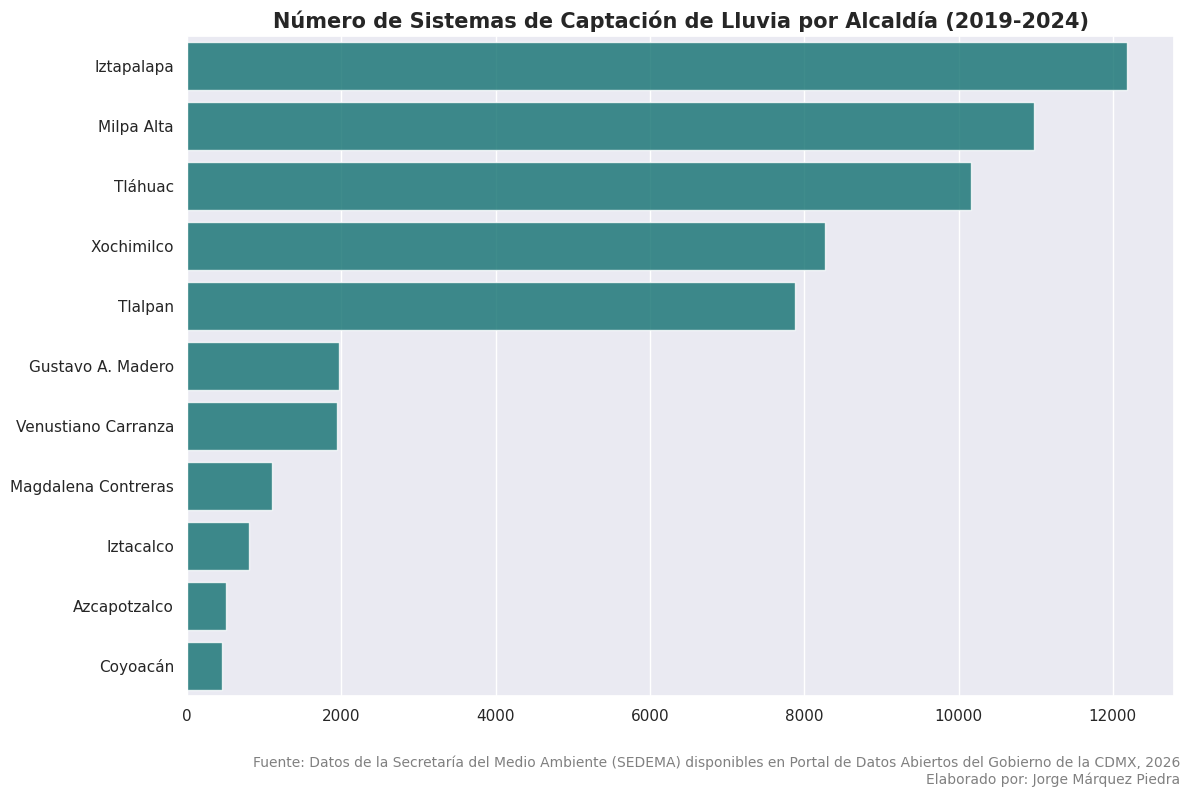

In [24]:
# Gráfica de conteo de sistemas de captación por alcaldía
plt.figure(figsize=(12, 8))
sns.set_theme()
sns.countplot(data = cap_ll, y = 'alcaldia', order = cap_ll['alcaldia'].value_counts().index, color = 'teal', alpha = 0.80)
plt.title('Número de Sistemas de Captación de Lluvia por Alcaldía (2019-2024)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks()
plt.figtext(0.99, 0.01, 'Fuente: Datos de la Secretaría del Medio Ambiente (SEDEMA) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('captacion_por_alcaldia.png', dpi = 300)
plt

In [25]:
# Crear columna de año usando la columna fecha_instalación
cap_ll['anio'] = cap_ll['fecha_instalacion'].dt.year
cap_ll

,longitud,latitud,expediente,pueblo,colonia_barrio,territorio,alcaldia,fecha_instalacion,instalado,anio
0,-98.975686,19.328924,J16NRB,Teotongo Acahualtepec,Campestre Potrero,Teotongo Acahualtepec,Iztapalapa,2019-07-24,Programa SCALL,2019.0
1,-98.970402,19.327016,J5WU9F,Teotongo Acahualtepec,Campestre Potrero,Teotongo Acahualtepec,Iztapalapa,2019-07-24,Programa SCALL,2019.0
2,-98.969184,19.326854,X4S7RV,Teotongo Acahualtepec,San Francisco Apolocalco,Teotongo Acahualtepec,Iztapalapa,2019-07-23,Programa SCALL,2019.0
3,-98.995963,19.334764,F5AXVR,Teotongo Acahualtepec,Miravalles,Teotongo Acahualtepec,Iztapalapa,2019-07-25,Programa SCALL,2019.0
4,-99.006770,19.353941,M8IJD1,Teotongo Acahualtepec,Santiago Acahualtepec 1A Amp,Teotongo Acahualtepec,Iztapalapa,2019-06-06,Programa SCALL,2019.0
...,...,...,...,...,...,...,...,...,...,...
57256,-99.125019,19.392931,99-ARDIMA-IZO-24,Santiago Norte (Barr),Santiago Norte (Barr),No Aplica,Iztacalco,2024-03-25,Programa SCALL,2024.0
57257,-99.012600,19.249100,99-ARLAER-XOO-24,Nativitas (Tulyehualco),Nativitas (Tulyehualco),No Aplica,Xochimilco,2024-05-30,Programa SCALL,2024.0
57258,-99.054697,19.299639,99-CALEAM-TLC-24,La Nopalera,La Nopalera,No Aplica,Tláhuac,2024-03-22,Programa SCALL,2024.0
57259,-99.064351,19.288027,9-RAAGMA-TLC-24,Del Mar (Norte),Del Mar (Norte),No Aplica,Tláhuac,2024-03-19,Programa SCALL,2024.0


In [26]:
# Convertir la columna 'anio' a Int64
cap_ll['anio'] = cap_ll['anio'].astype('Int64')
cap_ll

,longitud,latitud,expediente,pueblo,colonia_barrio,territorio,alcaldia,fecha_instalacion,instalado,anio
0,-98.975686,19.328924,J16NRB,Teotongo Acahualtepec,Campestre Potrero,Teotongo Acahualtepec,Iztapalapa,2019-07-24,Programa SCALL,2019
1,-98.970402,19.327016,J5WU9F,Teotongo Acahualtepec,Campestre Potrero,Teotongo Acahualtepec,Iztapalapa,2019-07-24,Programa SCALL,2019
2,-98.969184,19.326854,X4S7RV,Teotongo Acahualtepec,San Francisco Apolocalco,Teotongo Acahualtepec,Iztapalapa,2019-07-23,Programa SCALL,2019
3,-98.995963,19.334764,F5AXVR,Teotongo Acahualtepec,Miravalles,Teotongo Acahualtepec,Iztapalapa,2019-07-25,Programa SCALL,2019
4,-99.006770,19.353941,M8IJD1,Teotongo Acahualtepec,Santiago Acahualtepec 1A Amp,Teotongo Acahualtepec,Iztapalapa,2019-06-06,Programa SCALL,2019
...,...,...,...,...,...,...,...,...,...,...
57256,-99.125019,19.392931,99-ARDIMA-IZO-24,Santiago Norte (Barr),Santiago Norte (Barr),No Aplica,Iztacalco,2024-03-25,Programa SCALL,2024
57257,-99.012600,19.249100,99-ARLAER-XOO-24,Nativitas (Tulyehualco),Nativitas (Tulyehualco),No Aplica,Xochimilco,2024-05-30,Programa SCALL,2024
57258,-99.054697,19.299639,99-CALEAM-TLC-24,La Nopalera,La Nopalera,No Aplica,Tláhuac,2024-03-22,Programa SCALL,2024
57259,-99.064351,19.288027,9-RAAGMA-TLC-24,Del Mar (Norte),Del Mar (Norte),No Aplica,Tláhuac,2024-03-19,Programa SCALL,2024


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

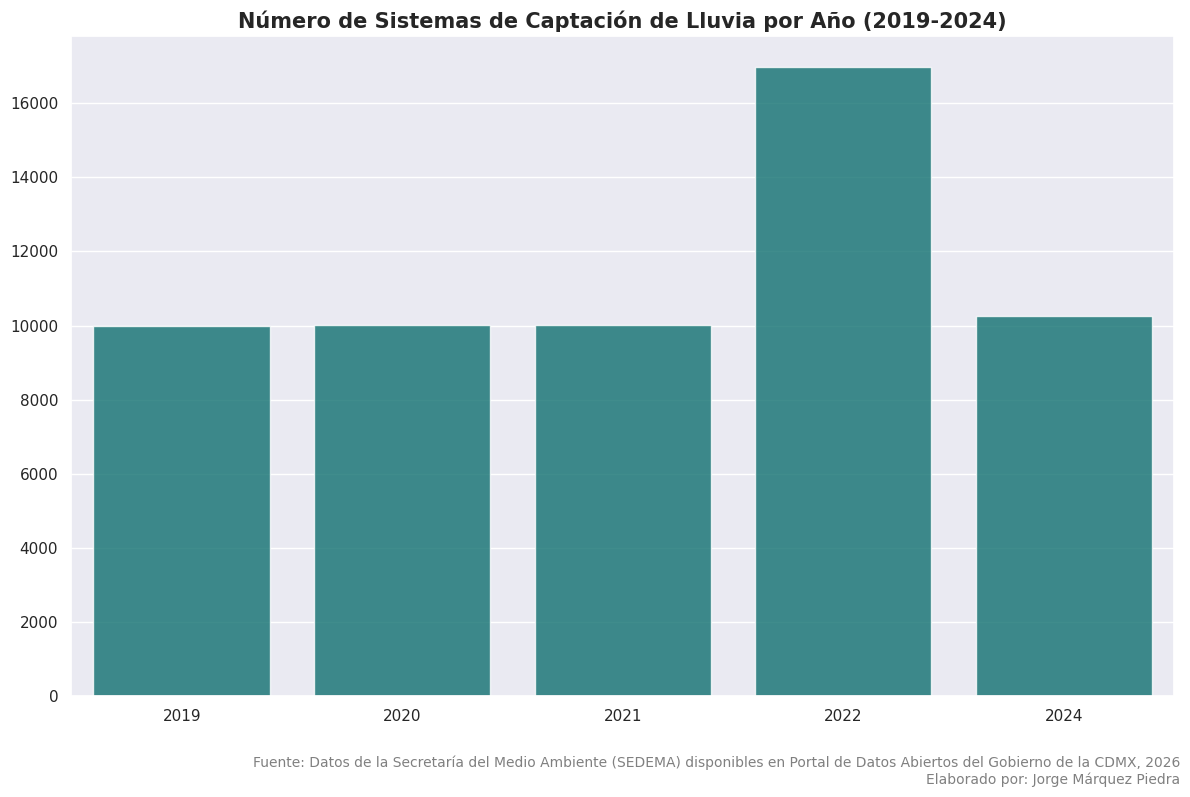

In [27]:
# Sistemas de captación por año
plt.figure(figsize=(12,8))
sns.set_theme()
sns.countplot(data = cap_ll, x = 'anio', color = 'teal', alpha = 0.80)
plt.title('Número de Sistemas de Captación de Lluvia por Año (2019-2024)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks()
plt.figtext(0.99, 0.01, 'Fuente: Datos de la Secretaría del Medio Ambiente (SEDEMA) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('captacion_por_anio.png', dpi = 300)
plt

In [28]:
# Crear columna de mes usando la columna fecha_instalación
cap_ll['mes'] = cap_ll['fecha_instalacion'].dt.month
cap_ll

,longitud,latitud,expediente,pueblo,colonia_barrio,territorio,alcaldia,fecha_instalacion,instalado,anio,mes
0,-98.975686,19.328924,J16NRB,Teotongo Acahualtepec,Campestre Potrero,Teotongo Acahualtepec,Iztapalapa,2019-07-24,Programa SCALL,2019,7.0
1,-98.970402,19.327016,J5WU9F,Teotongo Acahualtepec,Campestre Potrero,Teotongo Acahualtepec,Iztapalapa,2019-07-24,Programa SCALL,2019,7.0
2,-98.969184,19.326854,X4S7RV,Teotongo Acahualtepec,San Francisco Apolocalco,Teotongo Acahualtepec,Iztapalapa,2019-07-23,Programa SCALL,2019,7.0
3,-98.995963,19.334764,F5AXVR,Teotongo Acahualtepec,Miravalles,Teotongo Acahualtepec,Iztapalapa,2019-07-25,Programa SCALL,2019,7.0
4,-99.006770,19.353941,M8IJD1,Teotongo Acahualtepec,Santiago Acahualtepec 1A Amp,Teotongo Acahualtepec,Iztapalapa,2019-06-06,Programa SCALL,2019,6.0
...,...,...,...,...,...,...,...,...,...,...,...
57256,-99.125019,19.392931,99-ARDIMA-IZO-24,Santiago Norte (Barr),Santiago Norte (Barr),No Aplica,Iztacalco,2024-03-25,Programa SCALL,2024,3.0
57257,-99.012600,19.249100,99-ARLAER-XOO-24,Nativitas (Tulyehualco),Nativitas (Tulyehualco),No Aplica,Xochimilco,2024-05-30,Programa SCALL,2024,5.0
57258,-99.054697,19.299639,99-CALEAM-TLC-24,La Nopalera,La Nopalera,No Aplica,Tláhuac,2024-03-22,Programa SCALL,2024,3.0
57259,-99.064351,19.288027,9-RAAGMA-TLC-24,Del Mar (Norte),Del Mar (Norte),No Aplica,Tláhuac,2024-03-19,Programa SCALL,2024,3.0


In [29]:
# Hacer mapeo para cambiar datos inconsistentes
mapeo_mes = {
    1.0: 'Enero',
    2.0: 'Febrero',
    3.0: 'Marzo',
    4.0: 'Abril',
    5.0: 'Mayo',
    6.0: 'Junio',
    7.0: 'Julio',
    8.0: 'Agosto',
    9.0: 'Septiembre',
    10.0: 'Octubre',
    11.0: 'Noviembre',
    12.0: 'Diciembre'
}

cap_ll['mes'] = cap_ll['mes'].replace(mapeo_mes)
cap_ll

,longitud,latitud,expediente,pueblo,colonia_barrio,territorio,alcaldia,fecha_instalacion,instalado,anio,mes
0,-98.975686,19.328924,J16NRB,Teotongo Acahualtepec,Campestre Potrero,Teotongo Acahualtepec,Iztapalapa,2019-07-24,Programa SCALL,2019,Julio
1,-98.970402,19.327016,J5WU9F,Teotongo Acahualtepec,Campestre Potrero,Teotongo Acahualtepec,Iztapalapa,2019-07-24,Programa SCALL,2019,Julio
2,-98.969184,19.326854,X4S7RV,Teotongo Acahualtepec,San Francisco Apolocalco,Teotongo Acahualtepec,Iztapalapa,2019-07-23,Programa SCALL,2019,Julio
3,-98.995963,19.334764,F5AXVR,Teotongo Acahualtepec,Miravalles,Teotongo Acahualtepec,Iztapalapa,2019-07-25,Programa SCALL,2019,Julio
4,-99.006770,19.353941,M8IJD1,Teotongo Acahualtepec,Santiago Acahualtepec 1A Amp,Teotongo Acahualtepec,Iztapalapa,2019-06-06,Programa SCALL,2019,Junio
...,...,...,...,...,...,...,...,...,...,...,...
57256,-99.125019,19.392931,99-ARDIMA-IZO-24,Santiago Norte (Barr),Santiago Norte (Barr),No Aplica,Iztacalco,2024-03-25,Programa SCALL,2024,Marzo
57257,-99.012600,19.249100,99-ARLAER-XOO-24,Nativitas (Tulyehualco),Nativitas (Tulyehualco),No Aplica,Xochimilco,2024-05-30,Programa SCALL,2024,Mayo
57258,-99.054697,19.299639,99-CALEAM-TLC-24,La Nopalera,La Nopalera,No Aplica,Tláhuac,2024-03-22,Programa SCALL,2024,Marzo
57259,-99.064351,19.288027,9-RAAGMA-TLC-24,Del Mar (Norte),Del Mar (Norte),No Aplica,Tláhuac,2024-03-19,Programa SCALL,2024,Marzo


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

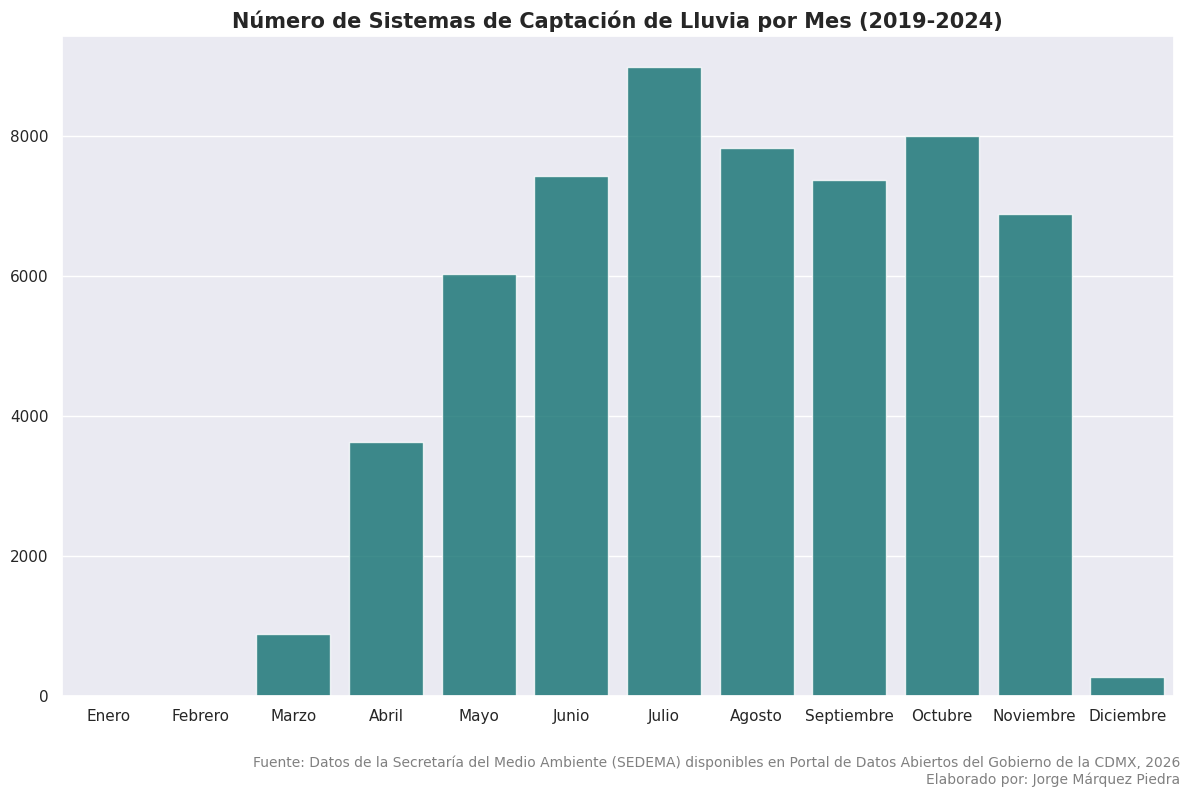

In [30]:
# Sistemas de captación por mes
orden_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

plt.figure(figsize=(12,8))
sns.set_theme()
sns.countplot(data = cap_ll, x = 'mes', order = orden_meses, color = 'teal', alpha = 0.80)
plt.title('Número de Sistemas de Captación de Lluvia por Mes (2019-2024)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks()
plt.figtext(0.99, 0.01, 'Fuente: Datos de la Secretaría del Medio Ambiente (SEDEMA) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('captacion_por_mes.png', dpi = 300)
plt

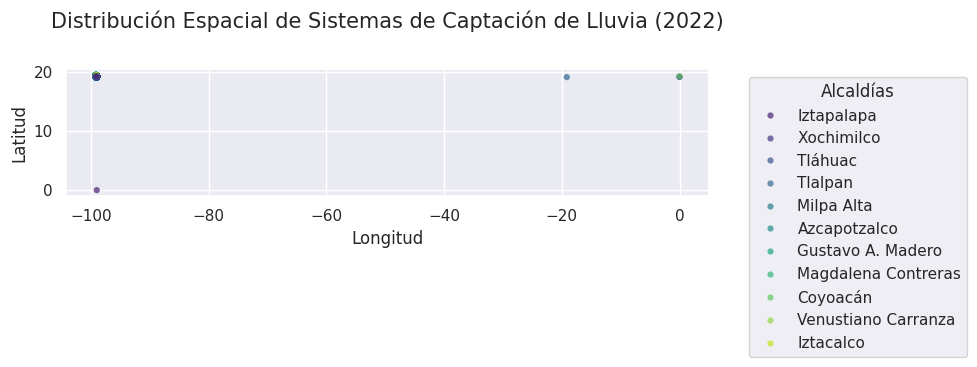

In [31]:
# Mapa (scatterplot) de sistemas de captación
plt.figure(figsize=(10, 10))
sns.set_theme()
sns.scatterplot(
    data = cap_ll,
    x = 'longitud',
    y = 'latitud',
    hue = 'alcaldia',
    palette = 'viridis',
    s = 20,
    alpha = 0.7,
    edgecolor = 'none'
)
plt.title('Distribución Espacial de Sistemas de Captación de Lluvia (2022)', fontsize=15, pad=30)
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Alcaldías')
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

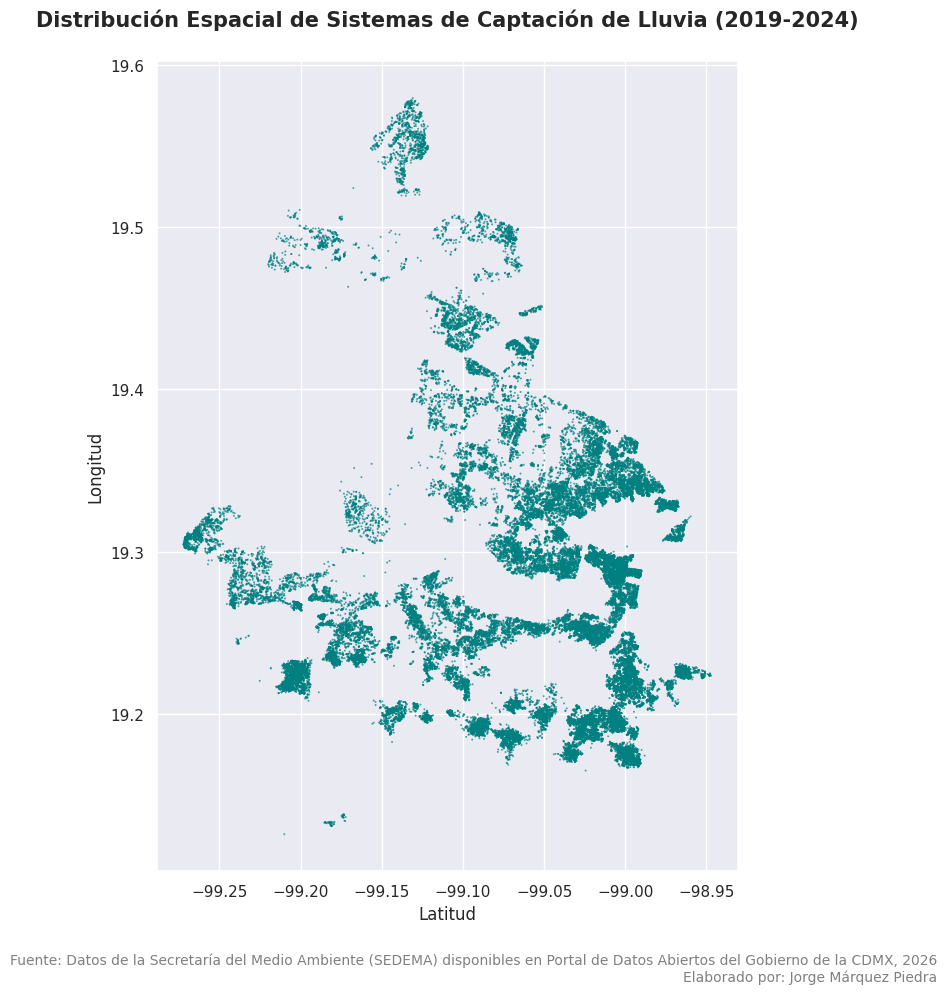

In [32]:
# Fitro usando coordenadas de la CDMX
# Eliminar puntos en 0 o latitudes erróneas
cap_ll_clean = cap_ll[
    (cap_ll['latitud'] > 19.0) & (cap_ll['latitud'] < 19.6) &
    (cap_ll['longitud'] > -99.4) & (cap_ll['longitud'] < -98.9)
].copy()

# Crear mapa
plt.figure(figsize=(10, 10))
sns.set_theme()
sns.scatterplot(
    data = cap_ll_clean,
    x = 'longitud',
    y = 'latitud',
    color = 'teal',
    s = 2,
    alpha = 0.7,
    edgecolor = 'none'
)
plt.title('Distribución Espacial de Sistemas de Captación de Lluvia (2019-2024)', fontsize = 15, fontweight = 'bold', pad = 25, loc = 'center')
plt.xlabel('Latitud')
plt.ylabel('Longitud')
plt.gca().set_aspect('equal', adjustable = 'box')
plt.figtext(0.99, 0.01, 'Fuente: Datos de la Secretaría del Medio Ambiente (SEDEMA) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('mapa_sistemas_captacion.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

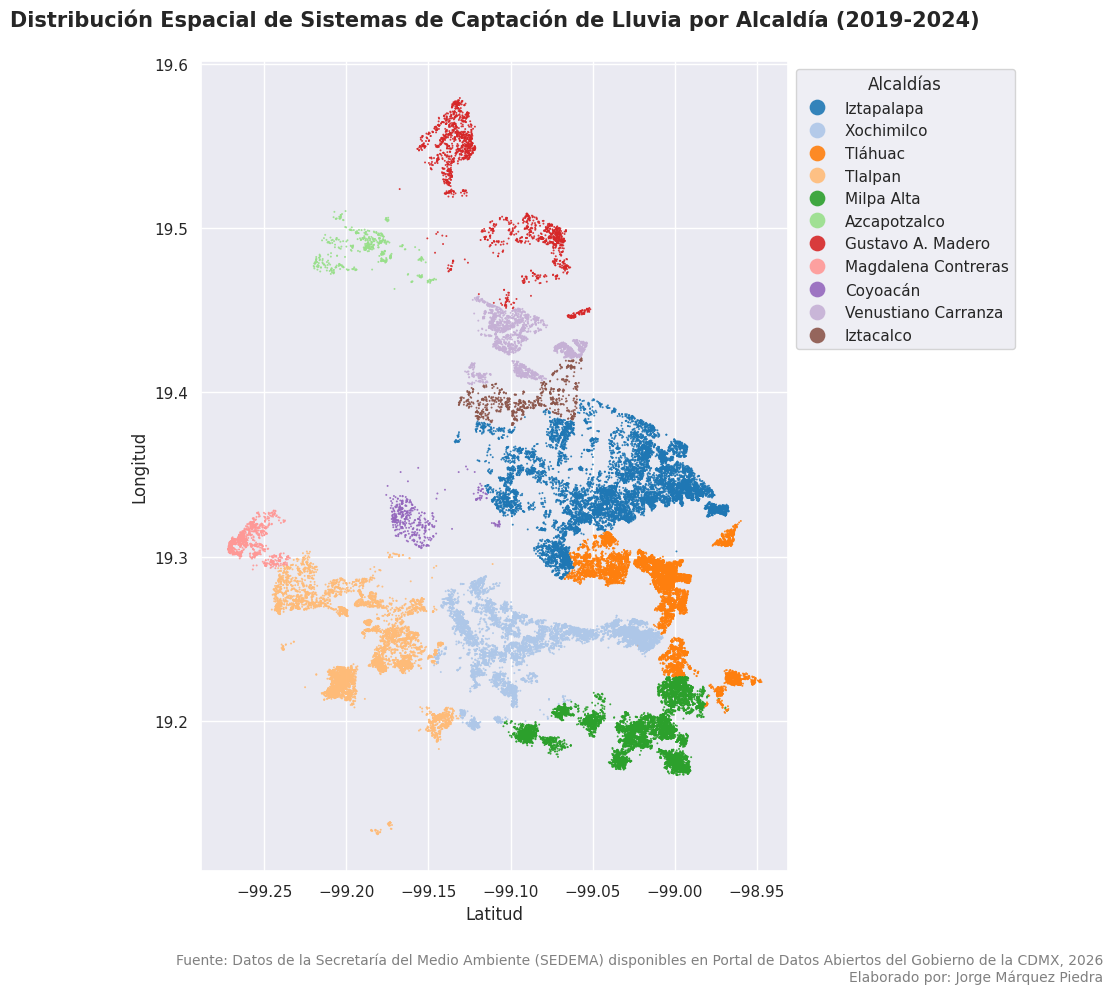

In [33]:
# Fitro usando coordenadas de la CDMX
# Eliminar puntos en 0 o latitudes erróneas
cap_ll_clean = cap_ll[
    (cap_ll['latitud'] > 19.0) & (cap_ll['latitud'] < 19.6) &
    (cap_ll['longitud'] > -99.4) & (cap_ll['longitud'] < -98.9)
].copy()

# Crear mapa
plt.figure(figsize=(12, 10))
sns.set_theme()
sns.scatterplot(
    data = cap_ll_clean,
    x = 'longitud',
    y = 'latitud',
    hue = 'alcaldia',
    palette = 'tab20',
    s = 2,
    alpha = 0.9,
    edgecolor = 'none'
)
plt.title('Distribución Espacial de Sistemas de Captación de Lluvia por Alcaldía (2019-2024)', fontsize = 15, fontweight = 'bold', pad = 25, loc = 'center')
plt.xlabel('Latitud')
plt.ylabel('Longitud')
plt.legend(bbox_to_anchor = (1.0, 1), loc = 'upper left', title = 'Alcaldías', markerscale = 8)
plt.gca().set_aspect('equal', adjustable = 'box')
plt.figtext(0.99, 0.01, 'Fuente: Datos de la Secretaría del Medio Ambiente (SEDEMA) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('mapa_sistemas_captacion_alcaldia.png', dpi = 300)
plt

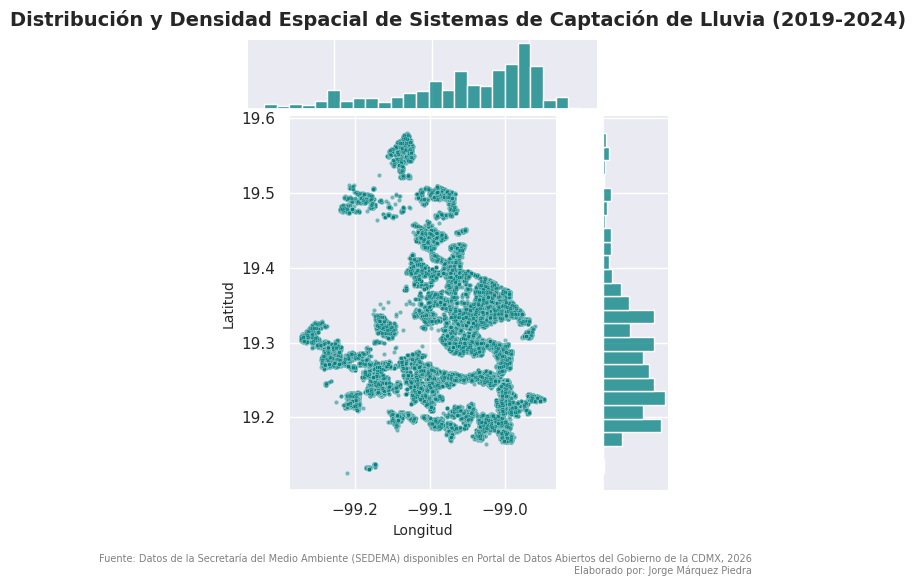

In [34]:
# Distribución y densidad
sns.set_theme()
g = sns.jointplot(
    data = cap_ll_clean,
    x = 'longitud',
    y = 'latitud',
    kind = 'scatter',
    color = 'teal',
    alpha = 0.5,
    s = 10,
    marginal_kws = dict(bins=25, fill=True),
    ratio = 5,   # Mapa es 5 veces más grande que los histogramas
    space = 0.1  # Espacio entre el mapa y las barras
)
g.ax_joint.set_aspect('equal')
g.fig.suptitle('Distribución y Densidad Espacial de Sistemas de Captación de Lluvia (2019-2024)',
               fontsize = 14,
               fontweight = 'bold',
               y = 0.95)
g.set_axis_labels('Longitud', 'Latitud', fontsize=10)

# Corrección de Proporción (Aspect Ratio), esto evita que la ciudad se vea "estirada" o "aplastada"
g.ax_joint.set_aspect('equal')

g.fig.text(0.99, 0.01,
           'Fuente: Datos de la Secretaría del Medio Ambiente (SEDEMA) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra',
           horizontalalignment='right', fontsize=7, color='gray')

# Ajuste de márgenes
plt.subplots_adjust(left = 0.15, right = 0.85, top = 0.9, bottom = 0.15)

plt.savefig('mapa_captacion_joint_scatter.png', dpi = 300, bbox_inches = 'tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 's'
  cset = contour_func(


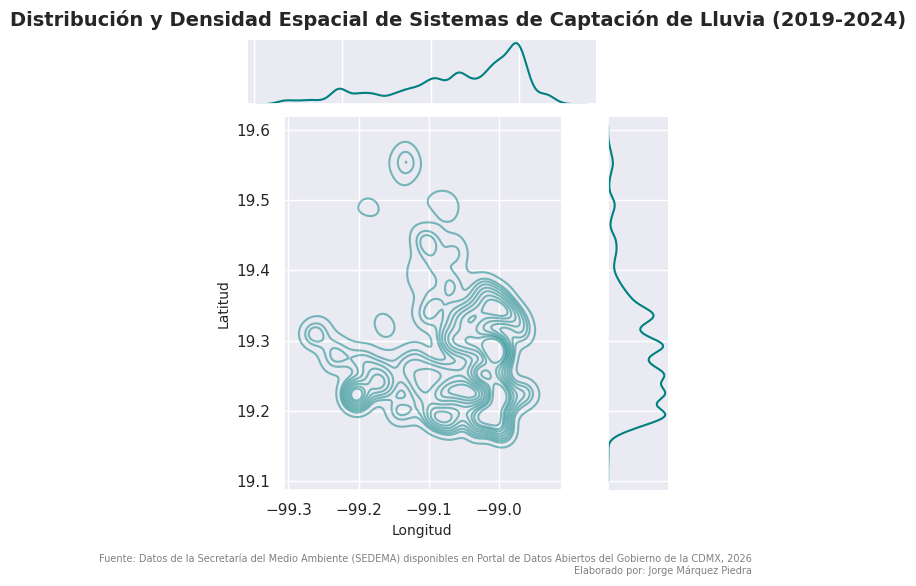

In [35]:
# Distribución y densidad
sns.set_theme()
g = sns.jointplot(
    data = cap_ll_clean,
    x = 'longitud',
    y = 'latitud',
    kind = 'kde',
    color = 'teal',
    alpha = 0.5,
    s = 10
)
g.fig.suptitle('Distribución y Densidad Espacial de Sistemas de Captación de Lluvia (2019-2024)',
               fontsize = 14,
               fontweight = 'bold',
               y = 0.95)
g.set_axis_labels('Longitud', 'Latitud', fontsize = 10)

# Corrección de Proporción (Aspect Ratio), esto evita que la ciudad se vea "estirada" o "aplastada"
g.ax_joint.set_aspect('equal')

g.fig.text(0.99, 0.01,
           'Fuente: Datos de la Secretaría del Medio Ambiente (SEDEMA) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra',
           horizontalalignment = 'right', fontsize = 7, color = 'gray')

# Ajuste de márgenes
plt.subplots_adjust(left = 0.15, right = 0.85, top = 0.9, bottom = 0.15)

plt.savefig('mapa_captacion_joint_kde.png', dpi = 300, bbox_inches = 'tight')
plt.show()

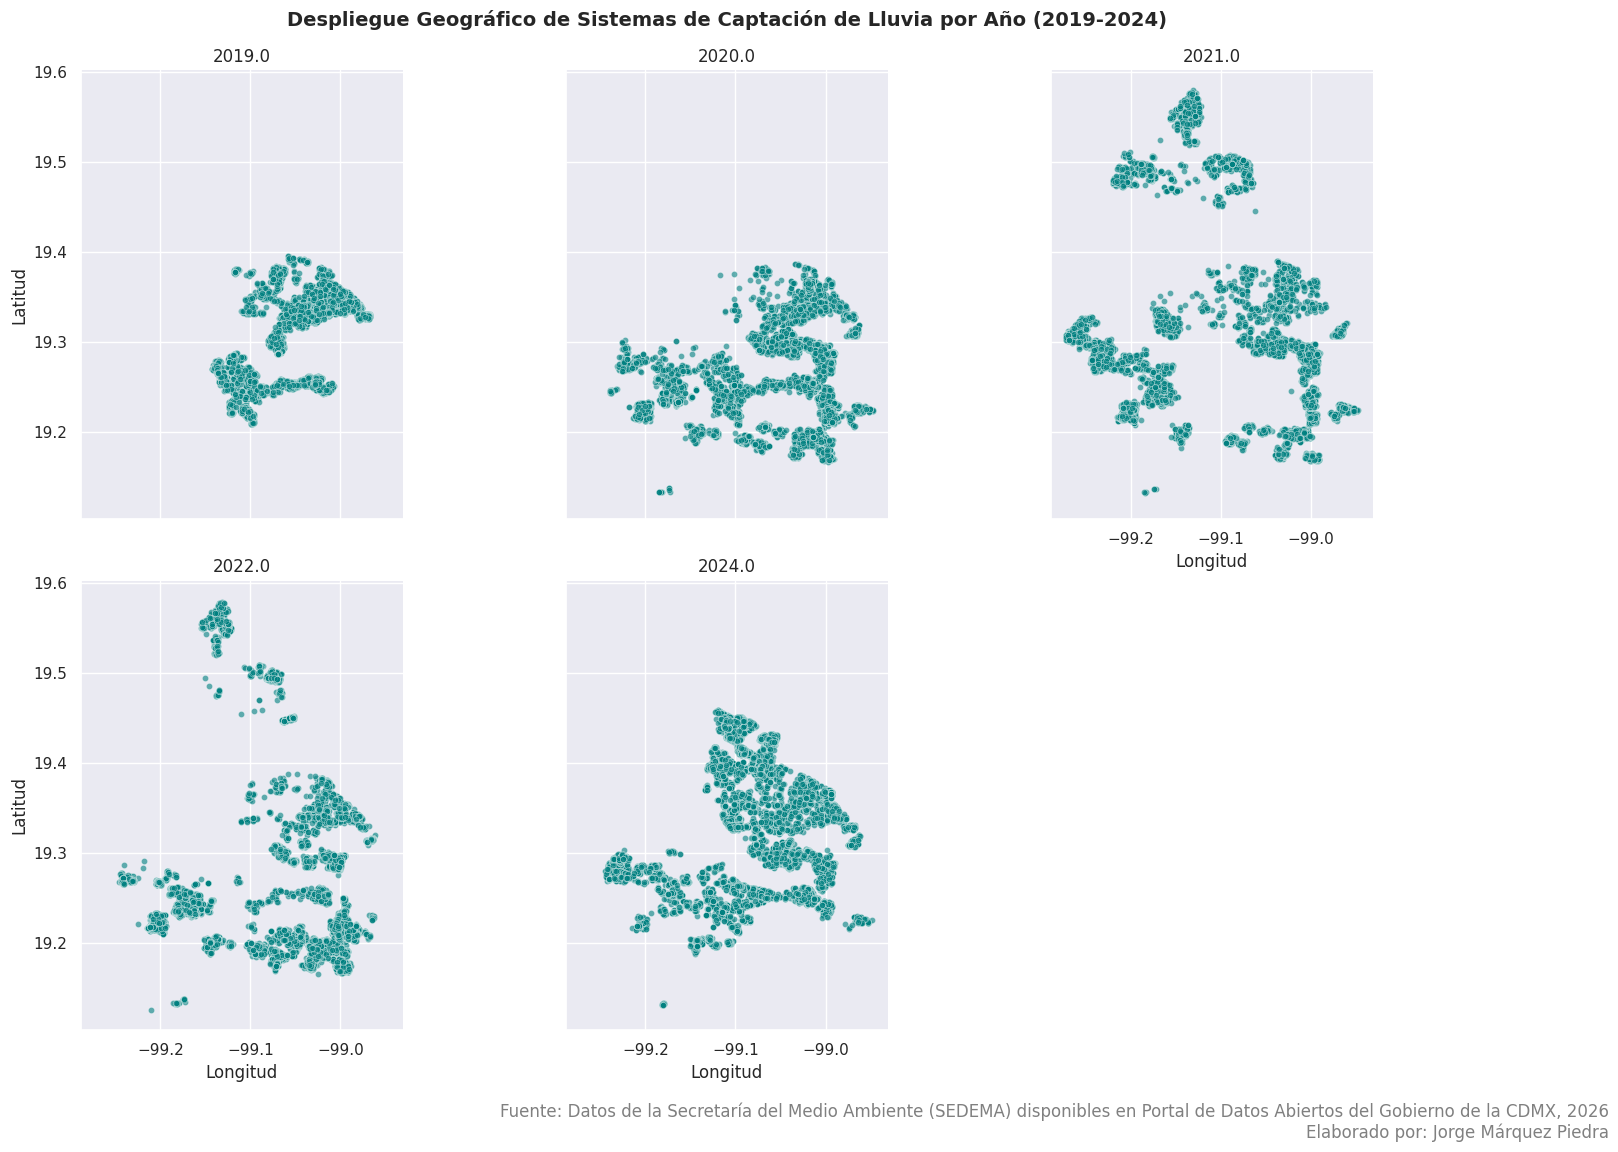

In [36]:
# Mapas por días de la semana
g = sns.FacetGrid(cap_ll_clean, col = "anio", col_wrap = 3, height = 6)
g.map_dataframe(
    sns.scatterplot,
    x = "longitud",
    y = "latitud",
    s = 20,
    alpha = 0.6,
    color = 'teal'
)

g.set_titles("{col_name}")
g.set_axis_labels("Longitud", "Latitud")
plt.subplots_adjust(top = 1.5)
g.fig.suptitle('Despliegue Geográfico de Sistemas de Captación de Lluvia por Año (2019-2024)',
               fontsize = 14,
               fontweight = 'bold',
               y = 0.95)

# Aplicar aspect equal a todos los plots
for ax in g.axes.flat:
    ax.set_aspect('equal', adjustable = 'box')

g.fig.text(0.99, 0.01,
           'Fuente: Datos de la Secretaría del Medio Ambiente (SEDEMA) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra',
           horizontalalignment = 'right', fontsize = 12, color = 'gray')
plt.subplots_adjust(left = 0.1, right = 0.9, top = 0.9, bottom = 0.1)
plt.savefig('mapa_captacion_por_anio.png', dpi = 300, bbox_inches = 'tight')
plt.show()

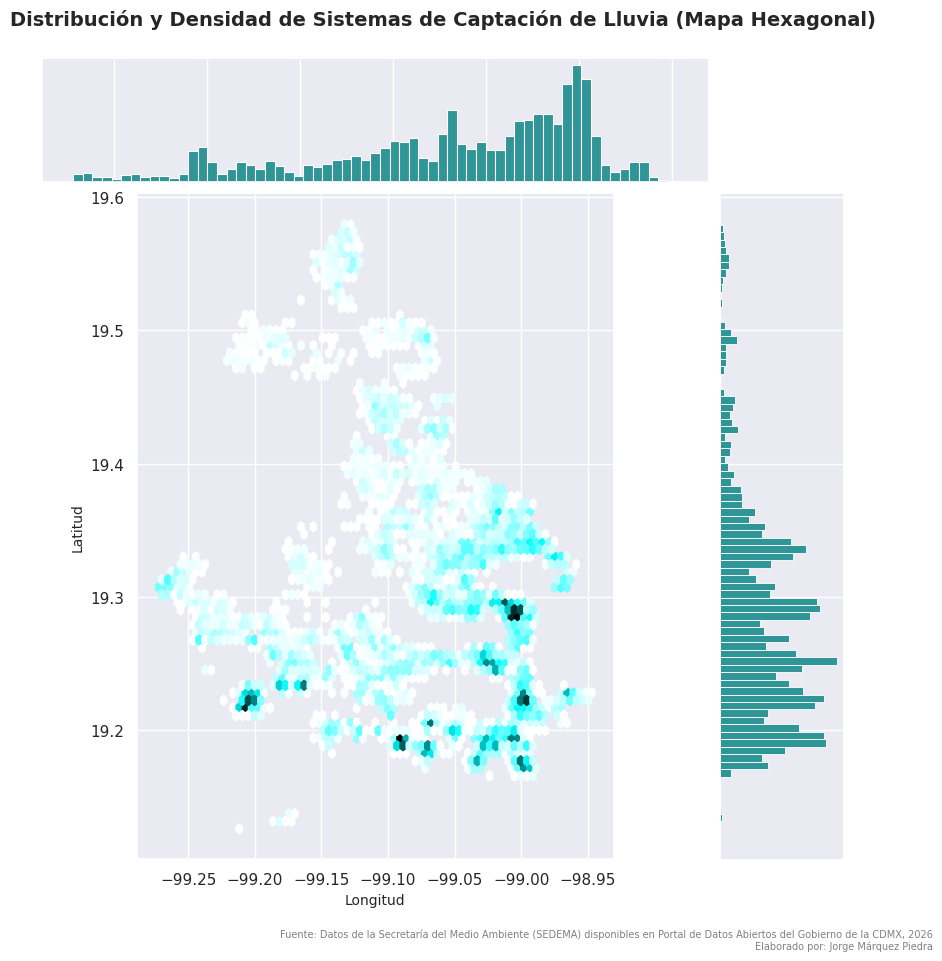

In [37]:
# Mapa Hexbins
sns.set_theme()
g = sns.jointplot(
    data = cap_ll_clean,
    x = 'longitud',
    y = 'latitud',
    kind = 'hex',
    color = 'teal',
    gridsize = 70,       # Tamaño de los hexágonos (mayor número = más pequeños)
    mincnt = 1,          # No dibujar hexágonos donde no hay datos
    ratio = 5,
    space = 0.1,
    height = 10,
    marginal_kws = dict(color = 'teal', fill = True, alpha = 0.8)
)

g.ax_joint.set_aspect('equal')

g.fig.suptitle('Distribución y Densidad de Sistemas de Captación de Lluvia (Mapa Hexagonal)',
               fontsize = 14, fontweight = 'bold', y = 0.95)

g.set_axis_labels('Longitud', 'Latitud', fontsize = 10)

g.fig.text(0.99, 0.01,
           'Fuente: Datos de la Secretaría del Medio Ambiente (SEDEMA) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra',
           horizontalalignment = 'right', fontsize = 7, color = 'gray')

plt.subplots_adjust(left = 0.1, right = 0.9, top = 0.9, bottom = 0.1)

plt.savefig('mapa_captacion_hexagonal.png', dpi = 300, bbox_inches = 'tight')
plt.show()